<a href="https://colab.research.google.com/github/monarchythe/Agentic-AI-Lab-Work/blob/main/n_queens_Solving_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solving the n-qeens Problem using Local Search

Student Name: Monarch Nigam

I have used the following AI tools: chat gpt(Mentioned) at some places

I understand that my submission needs to be my own work: Monarch Nigam


## Learning Outcomes

* Implement multiple hill climbing search variants to solve the n-qeens problem.
* Apply simulated annealing with appropriate temperature scheduling to overcome local optima.
* Compare algorithm performance using runtime, solution quality, and success rate metrics.
* Analyze and visualize algorithm performance across different problem sizes.
* Graduate Students: Design and test alternative local move operators to improve search efficiency.

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook as a HTML file.

## The n-qeens Problem

* __Goal:__ Find an arrangement of $n$ qeens on a $n \times n$ chess board so that no qeen is on the same row, column or diagonal as any other qeen.

* __State space:__ An arrangement of the qeens on the board. We restrict the state space to arrangements where there is only a single qeen per column. We represent a state as an integer vector $\mathbf{q} = \{q_1, q_2, \dots, q_n\}$, each number representing the row positions of the qeens from left to right. We will call a state a "board."

* __Objective function:__ The number of pairwise conflicts (i.e., two qeens in the same row/column/diagonal).
The optimization problem is to find the optimal arrangement $\mathbf{q}^*$ of $n$ qeens on the board can be written as:

  > minimize: $\mathrm{conflicts}(\mathbf{q})$
  >
  > subject to: $\mathbf{q} \ \text{contains only one qeen per column}$

  Note: the constraint (subject to) is enforced by the definition of the state space.

* __Local improvement move:__ Move one qeen to a different row in its column.

* __Termination:__ For this problem there is always an arrangement $\mathbf{q}^*$ with $\mathrm{conflicts}(\mathbf{q}^*) = 0$, however, the local improvement moves might end up in a local minimum.

## Helper functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

np.random.seed(1234)


def random_board(n):
    """Creates a random board of size n x n. Note that only a single queen is placed in each column!"""

    return(np.random.randint(0,n, size = n))

def comb2(n): return n*(n-1)//2 # this is n choose 2 equivalent to math.comb(n, 2); // is int division

def conflicts(board):
    """Calculate the number of conflicts, i.e., the objective function."""

    n = len(board)

    horizontal_cnt = [0] * n
    diagonal1_cnt = [0] * 2 * n
    diagonal2_cnt = [0] * 2 * n

    for i in range(n):
        horizontal_cnt[board[i]] += 1
        diagonal1_cnt[i + board[i]] += 1
        diagonal2_cnt[i - board[i] + n] += 1

    return sum(map(comb2, horizontal_cnt + diagonal1_cnt + diagonal2_cnt))

# decrease the font size to fit larger boards
def show_board(board, cols = ['white', 'gray'], fontsize = 48):
    """display the board"""

    n = len(board)

    # create chess board display
    display = np.zeros([n,n])
    for i in range(n):
        for j in range(n):
            if (((i+j) % 2) != 0):
                display[i,j] = 1

    cmap = colors.ListedColormap(cols)
    fig, ax = plt.subplots()
    ax.imshow(display, cmap = cmap,
              norm = colors.BoundaryNorm(range(len(cols)+1), cmap.N))
    ax.set_xticks([])
    ax.set_yticks([])

    # place qeens. Note: Unicode u265B is a black qeen
    for j in range(n):
        plt.text(j, board[j], u"\u265B", fontsize = fontsize,
                 horizontalalignment = 'center',
                 verticalalignment = 'center')

    print(f"board with {conflicts(board)} conflicts.")
    plt.show()

## Create a board

board with 4 conflicts.


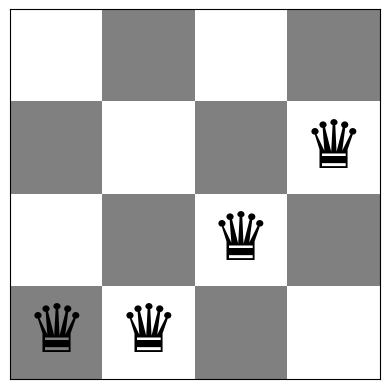

Queens (left to right) are at rows: [3 3 2 1]
Number of conflicts: 4


In [2]:
board = random_board(4)

show_board(board)
print(f"Queens (left to right) are at rows: {board}")
print(f"Number of conflicts: {conflicts(board)}")

A board $4 \times 4$ with no conflicts:

board with 0 conflicts.


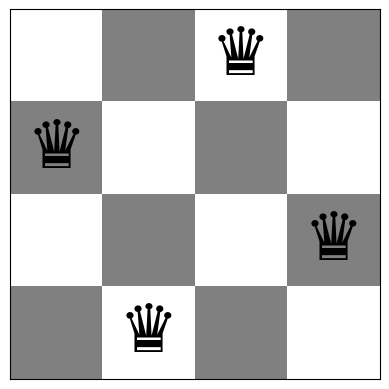

In [3]:
board = [1,3,0,2]
show_board(board)

# Tasks

## General [10 Points]

1. Make sure that you use the latest version of this notebook. Sync your forked repository and pull the latest revision.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally.
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

## Task 1: Steepest-ascend Hill Climbing Search [20 Points]

Calculate the objective function for all local moves (see definition of local moves above) and always choose the best among all local moves. If there are no local moves that improve the objective, then you have reached a local optimum.

### Implementing task 1


In [4]:
import numpy as np

def stepest_acent_hil_climb(n, max_step=10_000,debug = True,do_debugin_at_each_stp=1 ):
    """
    So as discussed in class
    we will start from a random board
    and then Repetedly -
      - try ALL niehbors
      - move to the one with the LOWEST conflicts
    the next stop when it can't improve anymore (local optimum) or max_step reached
    the max step is important because this will get stuck at local opitima and
    we want to end it when it is stuck
    """
    #from the helper function geting the random board
    brd = random_board(n)
    #storing the current conflicts
    curent_c = conflicts(brd)
    #storing the history of conflics in a list for later visualization
    histry = [curent_c]

    #initilising the step 0
    step = 0

    #keeping the wile loop conddition to break if the maximum steps has been covered
    while step < max_step:
        #starting with the step1
        step += 1

        #creating a copy of the current board as for now it is the best board we have yet
        best_brd = brd.copy()
        #storing the best conflict to keep the track of the conflicts
        best_c = curent_c
        # This will keep track of the specific queen move that gives the best result
        beast_move = None

        # Try moving each column's qeen to every other row
        for col in range(n):
            old_row = brd[col]

            for row in range(n):
                if row == old_row:
                  # skiping as "no move" (moving a qeen to its current row doesn't change anything)
                    continue
                # Make a temporary board to test the move
                niehbor = brd.copy()
                # Moveing the qeen in 'col' to 'row' in this temporary board
                niehbor[col] = row
                # Next Calculate conflicts for this new temporary board
                c = conflicts(niehbor)

                # keep the best (minimum conflicts) found so far among all possible moves
                if c < best_c:
                   # Update the best conflict count
                    best_c = c
                    # This new board is now the best board found
                    best_brd = niehbor
                    # Remember which move led to this best board
                    beast_move = (col, old_row, row)


        # Print what is happening if debug is on and it's time to print
        if debug and (step % do_debugin_at_each_stp == 0):
            print(f"[Step {step}] curent_conflicts={curent_c}  best_conflicts={best_c}")
            if beast_move is not None:
                col, oldr, newr = beast_move
                # Get details of the best move
                print(f"   -> move qeen in the this col={col}: row {oldr} -> {newr}")
            else:
                print("   -> no improving the move found (local optimum)") # No better move was found


        # If no niehbor improved (or it's the same), we're stuck (reached a local optimum)
        if best_c >= curent_c:
          # Stoping the search
            break

        # Otherwise, take the best move we found
        brd = best_brd # Update the main board to the best board found
        curent_c = best_c # Update the current conflict count
        # this histry for evaluation convergence
        histry.append(curent_c)

        # If solved (0 conflicts), stop early
        if curent_c == 0:
            break

    return {
        # returning the final board
        "brd": brd,
        # Return its conflict count
        "conflicts": curent_c,
        # Return how many steps it took
        "step": step,
         # Return the history of conflict counts
        "histry": histry
    }

### Result veiwing finction
which can be run after each task/algoritm objective funcotion

In [5]:
def showing_run_reslt_fucn(result, title="Result", fontsize=24):
    """
    Pass the dict returned by any hill-climb function.
    Prints summary + shows the board.
    """
    print("====", title, "====")
    print("step:", result.get("step"))
    print("Conflicts:", result.get("conflicts"))
    if "endurenc" in result:
        print("endurenc:", result["endurenc"])
    print("brd:", result["brd"])
    show_board(result["brd"], fontsize=fontsize)

Lets try to run the objective funton for the Stepest-ascend Hill Climbing

[Step 1] curent_conflicts=8  best_conflicts=5
   -> move qeen in the this col=3: row 1 -> 0
[Step 2] curent_conflicts=5  best_conflicts=3
   -> move qeen in the this col=1: row 4 -> 6
[Step 3] curent_conflicts=3  best_conflicts=2
   -> move qeen in the this col=3: row 0 -> 2
[Step 4] curent_conflicts=2  best_conflicts=1
   -> move qeen in the this col=5: row 1 -> 5
[Step 5] curent_conflicts=1  best_conflicts=0
   -> move qeen in the this col=6: row 7 -> 3
==== Task 1: Steepest-ascent ====
step: 5
Conflicts: 0
brd: [4 6 0 2 7 5 3 1]
board with 0 conflicts.


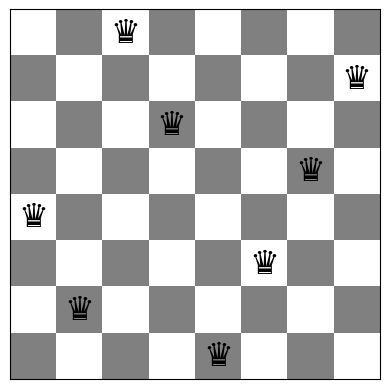

In [6]:
res = stepest_acent_hil_climb(8)
showing_run_reslt_fucn(res, title="Task 1: Steepest-ascent")

So As we can see form the Stepest Hiil climbing solution, we are not at the optimal solution and just getting stuck at the local optima,

## Task 2: Inefficient Stochastic Hill Climbing [10 Points]

Modify the algorithm for steepest-ascend hill climbing by choosing randomly from among all uphill moves till you have reached a local optimum.

### Implelmenting Task 2

In [7]:
# This is the function to solve the n Qeens problem using a not-so-efficient version of stochastic hill climbing
# It takes the board size 'n', a maximum number of steps 'max_step', and some debugging options.
def stchastic_hil_climb_ineficent(n, max_step=10_000, debug= True, do_debugin_at_each_stp=1):
    """
    Same niehbor evaluation as steepest-ascent, but:
      - collect ALL improving moves (lower conflicts than current)
      - pick one improving move at random
    Stop if there are no improving moves (local optimum).
    """

    # We start by getting a completely random arrangement of queens on the board.
    brd = random_board(n)
    # Then we figure out how many conflicts (queens attacking each other) there are on this starting board.
    curent_c = conflicts(brd)
    # We'll keep a record of how the number of conflicts changes over time, starting with the current conflicts.
    histry = [curent_c]

    # Let's start counting our steps from zero.
    step = 0

    # We'll keep trying to improve the board as long as we haven't hit our maximum allowed steps.
    while step < max_step:
        # Every time we try to make an improvement, we count it as one step.
        step += 1

        # We need a list to temporarily store all the possible moves that would actually make the board better (reduce conflicts).
        improving_qeen_moves = []

        # We're going to look at each column on the board, one by one.
        for col in range(n):
            # Remember where the queen in this column is currently sitting.
            old_row = brd[col]
            # Now, for the queen in this column, we'll try moving her to every single row in that same column.
            for row in range(n):
                # If the 'new' row is actually the same row the queen is already on, there's no point in checking it.
                if row == old_row:
                    # So, we just skip to the next row option.
                    continue

                # Let's make a temporary copy of our current board to see what happens if we move a queen. We don't want to mess up the actual board yet!
                niehbor = brd.copy()
                # On this temporary board, we move the queen in the current column to the new row we're testing.
                niehbor[col] = row
                # Now, we calculate how many conflicts this 'new' board arrangement has.
                c = conflicts(niehbor)

                # If this new arrangement has fewer conflicts than our current best board...
                if c < curent_c:
                    # ...then we add this potential move (the new board and its conflict count) to our list of good moves.
                    improving_qeen_moves.append((niehbor, c))

        # After checking all possible moves, if our list of improving moves is empty...
        if len(improving_qeen_moves) == 0:
            # ...it means we can't find any single move that makes the board better, so we're stuck in a 'local optimum'. Time to stop.
            break

        # If debugging is turned on and it's time to show progress...
        if debug and (step % do_debugin_at_each_stp == 0):
            # ...we print out the current conflicts and how many good moves we found.
            print(f"[Step {step}] curent_conflicts={curent_c}  improving_qeen_moves={len(improving_qeen_moves)}")

        # This is another check, basically the same as before: if there are no moves that make things better...
        if len(improving_qeen_moves) == 0:
            # ...and if debugging is on...
            if debug:
                # ...we print a message saying we're stuck.
                print("   -> no improving move found (local optimum)")
            # And then we stop the whole process.
            break

        # If there *are* good moves, we randomly pick one from our list. This is what makes it \"stochastic.\"
        idx = np.random.randint(0, len(improving_qeen_moves))
        # We update our main board to be this randomly chosen better board, and update its conflict count.
        brd, curent_c = improving_qeen_moves[idx]
        # We record this new conflict count in our history list to see how we're doing.
        histry.append(curent_c)

        # If we've managed to get zero conflicts, meaning we found a perfect solution...
        if curent_c == 0:
            # ...then we can stop early because we've achieved our goal!
            break

    # Finally, when the search stops (either by finding a solution, getting stuck, or hitting max steps), we give back all the useful information.
    return {
        # This is the best board arrangement we found.
        "brd": brd,
        # This is the number of conflicts on that final board.
        "conflicts": curent_c,
        # This tells us how many steps it took to get to this result.
        "step": step,
        # And here's the full journey of conflict counts, step by step.
        "histry": histry
    }

So now we will use the same function to show the resuults that we used earlier

[Step 1] curent_conflicts=8  improving_qeen_moves=20
[Step 2] curent_conflicts=7  improving_qeen_moves=15
[Step 3] curent_conflicts=6  improving_qeen_moves=13
[Step 4] curent_conflicts=5  improving_qeen_moves=9
[Step 5] curent_conflicts=4  improving_qeen_moves=7
[Step 6] curent_conflicts=3  improving_qeen_moves=3
[Step 7] curent_conflicts=2  improving_qeen_moves=1
==== Task 2: Stochastic (inefficient) ====
step: 8
Conflicts: 1
brd: [6 1 3 7 7 4 2 0]
board with 1 conflicts.


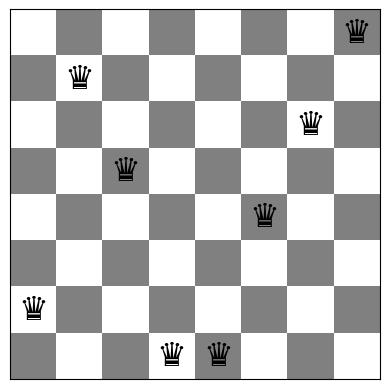

In [8]:
#so now we will run the stochastic hill climb
res2 = stchastic_hil_climb_ineficent(8, debug=True, do_debugin_at_each_stp=1)
#and see the results with the help of the above helper functions
showing_run_reslt_fucn(res2, "Task 2: Stochastic (inefficient)")

We can see that we are still not getting the optimal solutiokn

## Task 3: Efficient Stochastic Hill Climbing [20 Points]

Stochastic hill climbing is in practice always implemented in the following way:

1. Generate only a single random local niehbor at a time.
2. Accept the move if it has a better objective function value than the current state.
3. Repeat till a stopping criterion is met.

This is very efficient if each state has many possible successor states. This method is called "First-choice hill climbing" in the textbook AIMA and in practice this is just called "Stochastic Hill Climbing."

__Notes:__

* Detecting local optima is tricky since you never calculate the objective function for all local moves! A popular option is to stop if you were not able to improve the objective function during the last $x$ tries. You will need to argue what the right number for $x$ is. It will depend on the size of the board. Hint: You are sampling random local moves from the set of all possible moves with replacement and you want to make sure that you trie almost all before you stop.

### Implementing the task 3

In [9]:
# This function implements the "efficient" stochastic hill climbing algorithm, also known as First-choice hill climbing.
# It tries to find a good solution for the N-Queens problem.
def frst_choice_hill_clmbng_algo(n, max_step=100_000, endurenc=None, debug=True, do_debugin_at_each_stp = 1):
    """

    Efficient stochastic hill climbing (First-choice):
      - sample ONE random move at a time
      - accept immediately if it improves conflicts
    Stop if we fail to improve after 'endurenc' tries in a row

    """

    # If the 'endurenc' value isn't set, we calculate a default one.
    # This value determines how many unsuccessful attempts we'll tolerate before giving up.
    if endurenc is None:
        # We set 'endurenc' based on the board size (n) to give it enough chances.
        endurenc = 2 * n * (n - 1)

    # Let's start with a completely random arrangement of queens on the board.
    brd = random_board(n)
    # We calculate how many conflicts (attacking queens) this starting board has.
    curent_c = conflicts(brd)
    # We'll keep a list of the conflict counts over time to see our progress.
    histry = [curent_c]

    # We start our step counter at zero.
    step = 0
    # This counter tracks how many times we've tried a move without making the board better.
    not_improving_step_trys = 0

    # We keep trying to improve the board as long as we haven't hit our maximum allowed steps.
    while step < max_step:
        # Each attempt counts as one step.
        step += 1

        # If we've already found a perfect solution (0 conflicts), we can stop right away!
        if curent_c == 0:
            break

        # If we've tried too many times without improving the board, it means we're probably stuck.
        if not_improving_step_trys >= endurenc:
          # If debugging is on, we'll print a message saying we're stopping because we're stuck.
          if debug:
            print(f"[Stop] No improvement event after the {endurenc} no of trys -> local optimum/plateau")
          # And then we stop the search.
          break

        # We randomly pick a column where a queen is placed.
        col = np.random.randint(0, n)
        # We remember the current row of that queen.
        old_row = brd[col]

        # We then pick a random *new* row for that queen in the same column.
        row = np.random.randint(0, n)
        # We make sure the new row isn't the same as the old row, because that wouldn't be a move.
        while row == old_row:
            # If it is, we pick another random row.
            row = np.random.randint(0, n)

        # We create a temporary copy of our current board to test the new move.
        niehbor = brd.copy()
        # We move the queen in the chosen column to the randomly selected new row on this temporary board.
        niehbor[col] = row

        # We calculate how many conflicts this new temporary board has.
        c = conflicts(niehbor)

        # If this new board has fewer conflicts than our current board...
        if c < curent_c:
            #we accept this new, better board as our current board.
            brd = niehbor
            # We update our current conflict count to this new, lower value.
            curent_c = c

            # Since we found an improvement, we reset our 'no improvement' counter.
            not_improving_step_trys = 0

            # If debugging is on and it's time to print, we show the move and the new conflict count.
            if debug and (step % do_debugin_at_each_stp == 0):
              print(f"[Step {step}] ACCEPT move col={col} {old_row}->{row}  conflicts={curent_c}")
        # If the new board is not better than our current board (it's worse or the same)...
        else:
            # ...we increase our 'no improvement' counter.
            not_improving_step_trys += 1
            # If debugging is on and it's time to print, we indicate that we rejected the move and show the 'no improvement' count.
            if debug and (step % do_debugin_at_each_stp == 0):
              print(f"[Step {step}] reject move  conflicts={curent_c}  not_improving_step_trys={not_improving_step_trys}")
        # We add the current conflict count to our history list for later analysis.
        histry.append(curent_c)

    # Once the loop finishes (either found a solution, got stuck, or hit max steps), we return the results.
    return {
        # This is the final board arrangement we ended up with.
        "brd": brd,
        # This is the number of conflicts on that final board.
        "conflicts": curent_c,
        # This tells us how many total steps (iterations) the algorithm took.
        "step": step,
        # This is the 'endurenc' value that was used to determine when to stop if stuck.
        "endurenc": endurenc,
        # And here's the full history of conflict counts over all the steps.
        "histry": histry
    }

Now lets run the above objective funtion

[Step 1] reject move  conflicts=6  not_improving_step_trys=1
[Step 2] reject move  conflicts=6  not_improving_step_trys=2
[Step 3] reject move  conflicts=6  not_improving_step_trys=3
[Step 4] reject move  conflicts=6  not_improving_step_trys=4
[Step 5] reject move  conflicts=6  not_improving_step_trys=5
[Step 6] ACCEPT move col=4 3->1  conflicts=5
[Step 7] reject move  conflicts=5  not_improving_step_trys=1
[Step 8] reject move  conflicts=5  not_improving_step_trys=2
[Step 9] reject move  conflicts=5  not_improving_step_trys=3
[Step 10] reject move  conflicts=5  not_improving_step_trys=4
[Step 11] reject move  conflicts=5  not_improving_step_trys=5
[Step 12] reject move  conflicts=5  not_improving_step_trys=6
[Step 13] reject move  conflicts=5  not_improving_step_trys=7
[Step 14] reject move  conflicts=5  not_improving_step_trys=8
[Step 15] reject move  conflicts=5  not_improving_step_trys=9
[Step 16] reject move  conflicts=5  not_improving_step_trys=10
[Step 17] ACCEPT move col=7 2->5

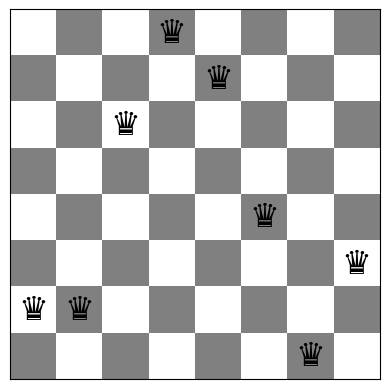

In [10]:
#storing the result in this result3 for the run of first choice hill climnin
res3 = frst_choice_hill_clmbng_algo(8, debug=True, do_debugin_at_each_stp=1)
#running the helper fuction for the stpes and the board
showing_run_reslt_fucn(res3, "Task 3: First-choice stochastic")

So as we can see we are still getting conflics and the algoritm is gettin stuck at this local optima again

## Task 4: Hill Climbing Search with Random Restarts [10 Points]

Hill climbing will often end up in local optima. Restart the each of the three hill climbing algorithm up to 100 times with a random board to find a better (hopefully optimal) solution. Note that restart just means to run the algorithm several times starting with a new random board.

### Implenenting task 4
so first lets implement a common random restart function whihc can be clled with all the previous ojective funtions

In [11]:
import numpy as np

def randm_restart_Hclimb(hc_func, n, restarts=100, debug=False, **hc_kwargs):
    """
    Run a hill-climbing algorithm multiple times (random restarts).

    Inputs:
      hc_func: one of your hill-climbing functions (task1/task2/task3)
      n: board size
      restarts: max number of restarts (default 100)
      debug: print progress for each restart
      hc_kwargs: extra params for the hill-climb function (max_step, endurenc, etc.)

    Output:
      best result dict + extra stats


    """

    # Initialize beast_result_so_far to None, as no solution has been found yet.
    beast_result_so_far = None
    # Initialize best_conflicts to a very large number (infinity) to ensure any found conflict count is lower.
    best_conf = float("inf")
    # Initialize total_step to keep track of the total steps taken across all restarts.
    total_step = 0

    # Loop through the specified number of restarts (trials).
    for r in range(1, restarts + 1):
        # Run one episode of the hill-climbing function, starting from a fresh random board internally.
        # hc_func is expected to handle the random board generation itself.
        res = hc_func(n, **hc_kwargs)

        # Add the number of steps taken in this restart to the total_step count.
        total_step += res.get("step", 0)
        # Get the final conflict count from the result of the current hill-climbing run.
        c = res["conflicts"]

        # Check if the current solution's conflict count is better (lower) than the best found so far.
        if c < best_conf:
            # If it is, update best_conflicts to the current conflict count.
            best_conf = c
            # Store the entire result dictionary as the beast_result_so_far found so far.
            beast_result_so_far = res

        # If debug mode is enabled, print the current restart's conflicts and the best conflicts seen up to this point.
        if debug:
            print(f"[restart {r}] conflicts={c} | best_so_far={best_conf}")

        # If a perfect solution (0 conflicts) is found, stop the restarts early.
        if best_conf == 0:
            break

    # Create a copy of the beast_result_so_far dictionary to add additional summary fields.
    beast_result_so_far = dict(beast_result_so_far)  # copy
    # Add the actual number of restarts used to find the best solution or until the limit was reached.
    beast_result_so_far["restarts_used"] = r
    # Add the total number of steps accumulated across all restarts.
    beast_result_so_far["total_step_over_restarts"] = total_step

    # Return the best result found, including the added summary statistics.
    return beast_result_so_far

Now letr try to run each and every hillclimbing with the random restart and see the results

[Step 1] curent_conflicts=12  best_conflicts=6
   -> move qeen in the this col=5: row 5 -> 1
[Step 2] curent_conflicts=6  best_conflicts=3
   -> move qeen in the this col=3: row 5 -> 0
[Step 3] curent_conflicts=3  best_conflicts=2
   -> move qeen in the this col=0: row 5 -> 1
[Step 4] curent_conflicts=2  best_conflicts=1
   -> move qeen in the this col=5: row 1 -> 3
[Step 5] curent_conflicts=1  best_conflicts=1
   -> no improving the move found (local optimum)
[restart 1] conflicts=1 | best_so_far=1
[Step 1] curent_conflicts=5  best_conflicts=3
   -> move qeen in the this col=5: row 0 -> 6
[Step 2] curent_conflicts=3  best_conflicts=2
   -> move qeen in the this col=1: row 1 -> 0
[Step 3] curent_conflicts=2  best_conflicts=2
   -> no improving the move found (local optimum)
[restart 2] conflicts=2 | best_so_far=1
[Step 1] curent_conflicts=3  best_conflicts=2
   -> move qeen in the this col=3: row 7 -> 0
[Step 2] curent_conflicts=2  best_conflicts=2
   -> no improving the move found (lo

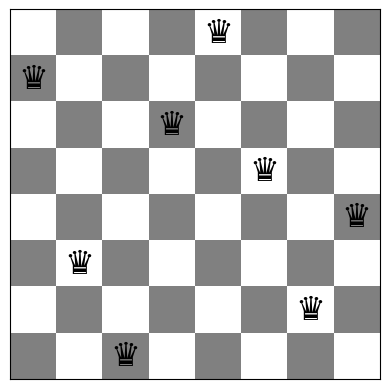

[Step 1] curent_conflicts=7  improving_qeen_moves=18
[Step 2] curent_conflicts=5  improving_qeen_moves=10
[Step 3] curent_conflicts=4  improving_qeen_moves=8
[Step 4] curent_conflicts=3  improving_qeen_moves=1
[Step 5] curent_conflicts=2  improving_qeen_moves=1
[restart 1] conflicts=1 | best_so_far=1
[Step 1] curent_conflicts=4  improving_qeen_moves=4
[Step 2] curent_conflicts=3  improving_qeen_moves=4
[Step 3] curent_conflicts=2  improving_qeen_moves=1
[restart 2] conflicts=0 | best_so_far=0
==== Task 4: Restart + Stochastic (inefficient) ====
step: 3
Conflicts: 0
brd: [3 1 6 4 0 7 5 2]
board with 0 conflicts.


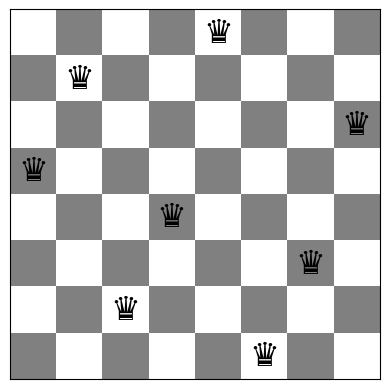

[Step 100] reject move  conflicts=2  not_improving_step_trys=33
[Stop] No improvement event after the 112 no of trys -> local optimum/plateau
[restart 1] conflicts=2 | best_so_far=2
[Step 100] reject move  conflicts=3  not_improving_step_trys=79
[Stop] No improvement event after the 112 no of trys -> local optimum/plateau
[restart 2] conflicts=3 | best_so_far=2
[Step 100] reject move  conflicts=1  not_improving_step_trys=53
[Stop] No improvement event after the 112 no of trys -> local optimum/plateau
[restart 3] conflicts=1 | best_so_far=1
[Step 100] reject move  conflicts=2  not_improving_step_trys=25
[Stop] No improvement event after the 112 no of trys -> local optimum/plateau
[restart 4] conflicts=2 | best_so_far=1
[Step 100] reject move  conflicts=3  not_improving_step_trys=79
[Stop] No improvement event after the 112 no of trys -> local optimum/plateau
[restart 5] conflicts=3 | best_so_far=1
[Step 100] reject move  conflicts=2  not_improving_step_trys=90
[Stop] No improvement even

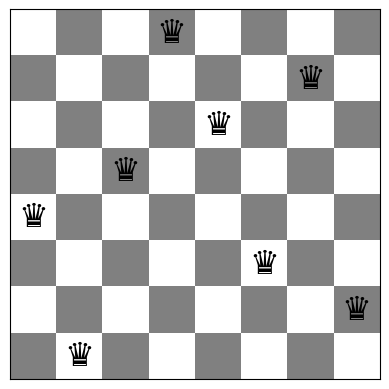

In [12]:
n = 8
best1 = randm_restart_Hclimb(stepest_acent_hil_climb, n, restarts=100, debug=True)
showing_run_reslt_fucn(best1, "Task 4: Restart + Steepest-ascent")
best2 = randm_restart_Hclimb(stchastic_hil_climb_ineficent, n, restarts=100, debug=True)
showing_run_reslt_fucn(best2, "Task 4: Restart + Stochastic (inefficient)")
best3 = randm_restart_Hclimb(frst_choice_hill_clmbng_algo, n, restarts=100, debug=True, do_debugin_at_each_stp = 100)
showing_run_reslt_fucn(best3, "Task 4: Restart + First-choice stochastic")

As we can see the random restart is able to get to the c = 0 , giving the optimal solution

## Task 5: Simulated Annealing [10 Points]

Simulated annealing is a form of efficient stochastic hill climbing that avoid local optima by also allowing downhill moves with a probability proportional to a temperature. The temperature is decreased in every iteration following an annealing schedule. You have to experiment with the annealing schedule (Google to find guidance on this).


1. Implement simulated annealing for the n-qeens problem.
2. Create a visualization of the search process (a line chart of how the number if conflict changes as the algorithm progresses).
3. Use this visualization for experiments with different choices for the annealing schedule and discuss what you have learned.

### Implementing task 5
1) so first we will code dor sumlated annealing which is based on the first-choice hilll climbing code


In [13]:
import numpy as np
import math
import matplotlib.pyplot as plt

# This function implements the Simulated Annealing algorithm to solve the N-Queens problem.
# It takes the board size 'n', a maximum number of steps, initial temperature 'T0', and a cooling rate 'cool_rate', plus a debug option.
def simulat_anealing_nqeens_algo(n, max_step=200_000, T0=5.0, cool_rate=0.995, debug=False):
    """
    Simulated annealing for n-qeens.

    - Start with random board
    - Each step: try one random niehbor (like first-choice)
    - Accept if better, else accept with prob exp(-ΔE/T)
    - Temperature schedule: T = T0 * (cool_rate ** t)  (geometric cooling)

    Returns:
      board, conflicts, step, histry (conflicts over time)
    """

    # First, let's get a random arrangement of queens on the board to start with.
    brd = random_board(n)
    # We calculate the initial number of conflicts on this random board. This is our 'energy' state.
    curent_confict = conflicts(brd)

    # We'll store the history of conflict counts to see how the algorithm progresses.
    histry = [curent_confict]

    # We start a loop that runs for a maximum number of steps.
    for t in range(1, max_step + 1):
        # We calculate the current temperature based on the initial temperature, cooling rate, and current step.
        T = T0 * (cool_rate ** t)

        # If the temperature drops too low (almost zero), it means the system is 'frozen', so we stop.
        if T < 1e-8:
            break

        # If we've found a solution with zero conflicts, we've succeeded and can stop early.
        if curent_confict == 0:
            break

        #  Now, let's try to find a 'neighbor' state (a slightly different board arrangement)
        # We randomly pick one column where a queen is placed.
        col = np.random.randint(0, n)
        # We remember the current row of that queen.
        old_row = brd[col]

        # We then pick a random *new* row for that queen in the same column.
        new_r = np.random.randint(0, n)
        # We make sure the new row isn't the same as the old row, because that wouldn't be a move.
        while new_r == old_row:
            new_r = np.random.randint(0, n)

        # We create a temporary copy of our current board to test this potential move.
        niehbor = brd.copy()
        # We move the queen in the chosen column to the randomly selected new row on this temporary board.
        niehbor[col] = new_r
        # We calculate how many conflicts this 'new' board arrangement has. This is the 'energy' of the new state.
        next_E = conflicts(niehbor)

        # We calculate the change in conflicts (energy) between the new state and the current state.
        delt_E = next_E - curent_confict

        #  Here's the core 'acceptance rule' of simulated annealing
        # If the new board has fewer conflicts (or the same), it's a better or equal state, so we always accept it.
        if delt_E <= 0:
            # We update our main board to this new, better or equal board.
            brd = niehbor
            # We update our current conflict count to this new value.
            curent_confict = next_E
        # If the new board has *more* conflicts (it's a worse state), we might still accept it sometimes...
        else:
            # now we calculate a probability of accepting this worse move, based on how much worse it is (delt_E) and the current temperature (T).
            accept_prob = math.exp(-delt_E / T)
            # (Using ChatGPT for the idea of comparing a random number (between 0 and 1) with the accept_prob)
            # next We generate a random number and if it's less than our calculated acceptance probability, we accept the worse move.
            if np.random.random() < accept_prob:
                # We update our main board to this new, worse board.
                brd = niehbor
                # We update our current conflict count to this new value.
                curent_confict = next_E

        # We add the current conflict count to our history list for later analysis and plotting.
        histry.append(curent_confict)

        # This is an optional small printout for debugging, showing progress every few thousand steps.
        if debug and t % 5000 == 0:
            print(f"[SA] step={t}  T={T:.4f}  conflicts={curent_confict}")

    # Finally, when the search stops, we return all the useful information.
    return {
        # This is the final board arrangement we ended up with.
        "brd": brd,
        # This is the number of conflicts on that final board.
        "conflicts": curent_confict,
        # This tells us how many total steps (iterations) the algorithm took.
        "step": len(histry) - 1,
        # And here's the full history of conflict counts over all the steps.
        "histry": histry,
        # We also return the initial temperature used.
        "T0": T0,
        # And the cooling rate used.
        "cool_rate": cool_rate
    }

2) next in the task 5 we have visualizatipon (line chart) funtion implementation

In [14]:
def plot_histry(result, title="Simulated Anealing Progress"):
    # Create a new figure for the plot
    plt.figure()
    # Plot the history of conflicts stored in the 'result' dictionary.
    plt.plot(result["histry"])
    plt.xlabel("Step")
    plt.ylabel("# Conflcts")
    # Set the title of the plot, including the algorithm's initial temperature (T0) and cooling rate (cool_rate).
    plt.title(f"{title} (T0={result['T0']}, cool_rate={result['cool_rate']})")
    plt.show()

lets try to run the simulat_anealing_nqeens_algo code first

==== SA Result ====
step: 841
Conflicts: 0
brd: [5 2 6 3 0 7 1 4]
board with 0 conflicts.


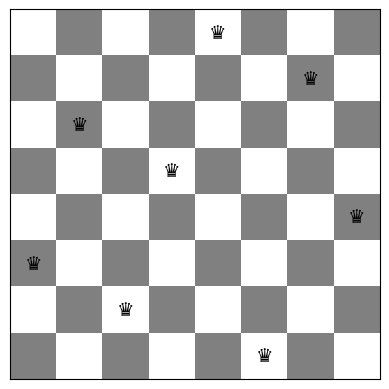

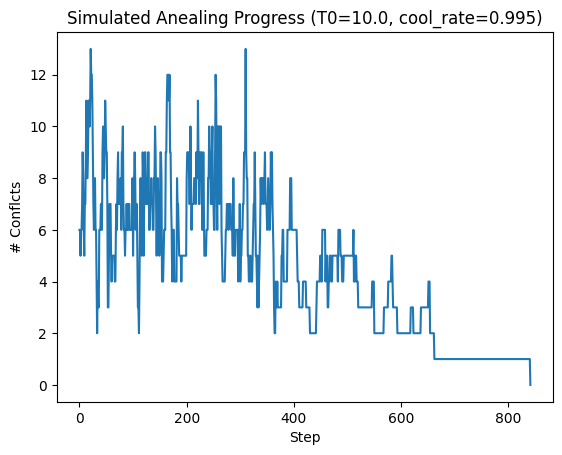

In [15]:
n = 8
res = simulat_anealing_nqeens_algo(n, max_step=200_000, T0=10.0, cool_rate=0.995, debug=True)
showing_run_reslt_fucn(res, title="SA Result", fontsize=14)
plot_histry(res)

3) Now last part of the task 5 is experimenting with different anealing schedules

T0=5.0, cool_rate=0.995 -> final conflicts=0, step=520


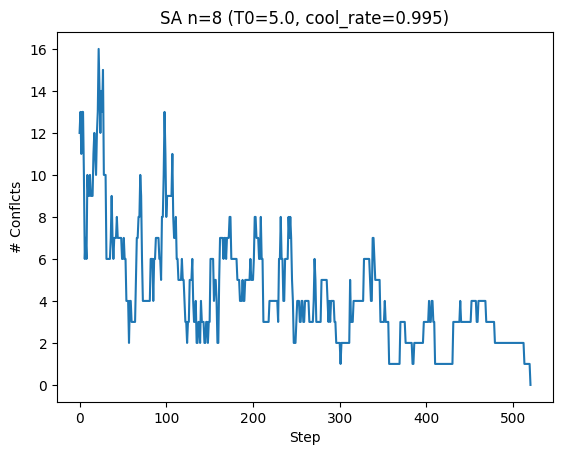

T0=10.0, cool_rate=0.995 -> final conflicts=0, step=979


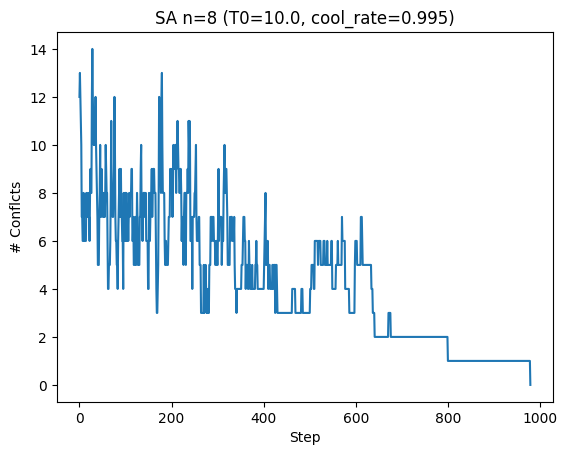

T0=10.0, cool_rate=0.999 -> final conflicts=0, step=3065


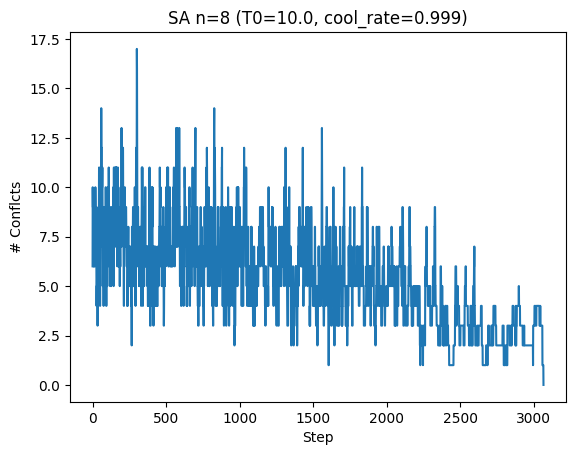

T0=20.0, cool_rate=0.995 -> final conflicts=0, step=1006


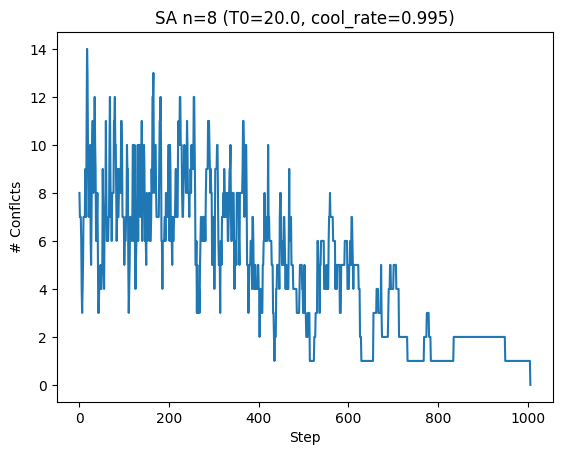

In [16]:
#defining a list of different temperature schedule configration to experiment with.
configration = [
    # Each tuple contains (Initial Temperature T0, Cooling Rate cool_rate).
    (5.0, 0.995),  # seting 1: Moderate T0
    (10.0, 0.995), # setting2: Higher T0
    (10.0, 0.999), # seting 3: Higher T0
    (20.0, 0.995), # seting 4: Even higher T0,
]

# Define the size of the N-Queens board for these experiments.
n = 8

# Loop through each defined setting (T0, cool_rate) to run Simulated Annealing.
for T0, cool_rate in configration:
    # Runing the simulated annealing algorithm with the current T0 and cool_rate values.
    # max_step is set to 200,000 for all runs.
    res = simulat_anealing_nqeens_algo(n, max_step=200_000, T0=T0, cool_rate=cool_rate)
    # Print the results for the current setting: T0, cool_rate, final conflicts, and total steps.
    print(f"T0={T0}, cool_rate={cool_rate} -> final conflicts={res['conflicts']}, step={res['step']}")
    # Plot the history of conflicts for the current run to visualize its progress.
    plot_histry(res, title=f"SA n={n}")

** Disucussion and observation on Experiments with Annealing Schedules**

so I tested the Simulated Annealing algorithm with diferent temp. schedules using the formula **T(t) = T0 ⋅ cool_rate^t** and observed how the number of conflicts changed over time. Due to the stochastic (random) nature of Simulated Annealing, results can vary slightly between runs. The key is to understand the general trends and the trade-offs involved.

lets dicuss the results ***Please note that the output results changed when i ran the above code again so i am mentioning both the runs observations***

**Run 1 Examples:**
*   T0=5.0, cool_rate=0.995 → final conflicts=0, step=520
*   T0=10.0, cool_rate=0.995 → final conflicts=0, step=979
*   T0=10.0, cool_rate=0.999 → final conflicts=0, step=3065
*   T0=20.0, cool_rate=0.995 → final conflicts=0, step=1006

**Run 2 Examples (showing variability):**
*   T0=5.0, cool_rate=0.995 → conflicts=0 in 629 step
*   T0=10.0, cool_rate=0.995 → conflicts=1 in 4134 step (did not fully solve)
*   T0=10.0, cool_rate=0.999 → conflicts=0 in 3001 step
*   T0=20.0, cool_rate=0.995 → conflicts=0 in 1127 step

**What We Learned from These Experiments:**

1.  **Stochasticity and Local Optima:** Simulated Annealing is a probabilistic algorithm. The fact that `T0=10.0, cool_rate=0.995` sometimes finds a solution (conflicts=0) and sometimes gets stuck (conflicts=1) highlights its non-deterministic nature. It tries to escape local optima by accepting worse moves with a certain probability, but this doesn't guarantee finding the global optimum every time, especially if the temperature schedule isn't ideal for the problem's landscape.

2.  **Trade-off between Exploration and Exploitation:**
    *   **T0 (Initial Temperature):** A higher `T0` means the algorithm starts by accepting 'bad' moves more readily. This encourages **exploration** of a wider area of the search space, potentially escaping deep local minima early on. However, if `T0` is too high, the search might wander aimlessly for too long.
    *   **Cool_rate (Cooling Schedule):** This dictates how quickly the temperature drops. A `cool_rate` closer to 1.0 (e.g., 0.999) means a **slower cooling schedule**, allowing more time for exploration and giving the algorithm more chances to jump out of local minima before settling. A smaller `cool_rate` (e.g., 0.995) leads to **faster cooling**, causing the algorithm to transition to **exploitation** (focusing on improving the current solution) more quickly. If cooling is too fast, the algorithm might get trapped in a local optimum.

3.  **Impact of Specific Schedules:**
    *   **`T0=5.0, cool_rate=0.995` (Moderate T0, Fast Cooling):** This combination generally performed well and found optimal solutions relatively quickly (e.g., 520-629 steps). A moderate starting temperature allows some initial exploration, and the relatively fast cooling pushes it towards a solution efficiently. This suggests a good balance for this `n=8` problem.
    *   **`T0=10.0, cool_rate=0.995` (Higher T0, Fast Cooling):** With a higher `T0`, the algorithm initially explores more aggressively. However, the relatively fast `cool_rate` of 0.995 might cause it to 'freeze' too quickly after this initial exploration, potentially trapping it in a local optimum (as seen in the `conflicts=1` result). It accepted many random “bad” moves early, but cooled too fast afterward.
    *   **`T0=10.0, cool_rate=0.999` (Higher T0, Slower Cooling):** This schedule kept the temperature high for a longer period. The higher `T0` provided strong initial exploration, and the `cool_rate` of 0.999 allowed this exploration to continue for many more steps (e.g., 3001-3065 steps) before the algorithm committed to exploitation. This often helps in escaping local minima and finding the global optimum, though at the cost of more computational steps.
    *   **`T0=20.0, cool_rate=0.995` (Even Higher T0, Fast Cooling):** Even with a very high `T0` for strong initial exploration, the fast `cool_rate` of 0.995 quickly reduces the temperature. While it did find optimal solutions in these examples, it sometimes took slightly more steps than the `T0=5.0` case, implying that the aggressive early exploration might not always be perfectly efficient if not followed by a sufficiently slow cooling phase.

**Overall Conclusion:**

The annealing schedule is crucial. A good schedule allows sufficient exploration early on (higher `T0`, slower `cool_rate`) to avoid getting stuck in local minima, but also ensures that the temperature eventually drops enough to guide the search towards a stable, optimal solution. Finding the optimal balance often requires experimentation and tuning for a specific problem instance.

## Task 6: Algorithm Behavior Analysis [20 Points]

### Comparison
Compare the algorithm using runtime and objective function values. Use boards of size 4 and 8 to explore how the different algorithms perform. Make sure that you run the algorithms for each board size several times (at least 100 times) with different starting boards and report averages.

Complete the following table

| Algorithm            | board size | Avg. Run time | Avg. number of conflicts | % of runs ending in optimal solution  |
| -------------------- | ---------- | ------------- | --------------------------------- | - |
| Steepest asc. HC     |     4      |               |                                   |   |
| Ineff. Stochastic HC |     4      |               |                                   |   |
| Efficient Stochastic HC |     4      |               |                                   |   |
| Simulated Annealing  |     4      |               |                                   |   |
| Steepest asc. HC     |     8      |               |                                   |   |
| Ineff. Stochastic HC |     8      |               |                                   |   |
| Efficient Stochastic HC |     8      |               |                                   |   |
| Simulated Annealing  |     8      |               |                                   |   |

Hint: See [Profiling Python Code](../HOWTOs/profiling_code.ipynb) for help about how to measure runtime in Python.

Add the used code here:

### Implementing task 6
lets first code thehelper fucntion which will take each algorithms and run it for atleast 100 times and record the data for the pandas dataframe

In [17]:
import time
import numpy as np
import pandas as pd
# multipel_trial_run_functio executes a given algorithm multiple times
# for a specified board size It then calculates and returns the average runtime,
# average final conflicts, and the percentage of runs that achieve an optimal solution (zero conflicts)
def multipel_trial_run_functio(algo_name, specific_hc_algo, n, trials=100):
    """
    Runing specific_hil_climbing_algo(n) many times and compute:
      - avg runtime
      - avg final conflicts
      - % optimal (conflicts == 0)
    """
    # Initialize a list to store the runtime for each trial.
    runtimes = []
    # Initialize a list to store the final conflict count for each trial.
    final_conflicts = []
    # Initialize a counter for the number of optimal solutions found.
    optimal_count = 0

    # Loop through the specified number of trials.
    for _ in range(trials):
        # Record the start time of the current trial.
        t0 = time.perf_counter()
        # Execute the given algorithm function for the board size 'n'.
        # Each algorithm is expected to internally start from a random board.
        res = specific_hc_algo(n)
        # Record the end time of the current trial.
        t1 = time.perf_counter()

        # Calculate the runtime for the current trial.
        rt = t1 - t0
        # Get the final conflict count from the result of the algorithm run.
        c = res["conflicts"]

        # Add the current runtime to the list of runtimes.
        runtimes.append(rt)
        # Add the current final conflict count to the list of final conflicts.
        final_conflicts.append(c)
        # If the conflict count is 0, increment the optimal solution counter.
        if c == 0:
            optimal_count += 1

    # Return a dictionary containing the summarized results for the algorithm.
    return {
        # The name of the algorithm.
        "Algorithm": algo_name,
        # The size of the board used for the trials.
        "brd size": n,
        # The average runtime across all trials.
        "Avg. Run time": np.mean(runtimes),
        # The average number of conflicts at the end of all trials.
        "Avg. number of conflicts": np.mean(final_conflicts),
        # The percentage of runs that resulted in an optimal solution (0 conflicts).
        "% optimal": 100 * optimal_count / trials
    }

defining algorithm rappers

In [18]:
# Wraper function for the steepest ascent hill climbing algorithm.
def algo_steepest(n):
    return stepest_acent_hil_climb(n)

# wrapper function for the inefficient stochastic hill climbing algorithm.
def algo_stoch_ineff(n):
    return stchastic_hil_climb_ineficent(n)

# Wraper function for the efficient stochastic hill climbing (first-choice) algorithm.
def algo_first_choice(n):
    return frst_choice_hill_clmbng_algo(n)

# Wraper function for the simulated annealing algorithm.
def algo_sa(n):
    # You can tune these parameters (max_step, T0, cool_rate) if needed for different board sizes or performance.
    return simulat_anealing_nqeens_algo(n, max_step=200_000, T0=10.0, cool_rate=0.995)

so next we are running exp for n=4 and n=8 and building the table

In [19]:
# Define the number of trials for each algorithm and board size.
trials = 100
# Define the board sizes to experiment with
sizes = [4, 8]

# Define a list of tuples,
#where each tuple contains the algorithm's name and
#its corresponding wraper function
algorithms = [
    ("Steepest asc. HC", algo_steepest),
    ("Ineff. Stochastic HC", algo_stoch_ineff),
    ("Efficient Stochastic HC", algo_first_choice),
    ("Simulated Annealing", algo_sa)
]

# Initialize an empty list to store the results (rows for the DataFrame).
rows = []

# Loop through each board size.
for n in sizes:
    # For each board size, loop through each algorithm.
    for name, fn in algorithms:
        # Run the multiple trial function for the current algorithm, board size, and number of trials,
        # then append the returned results (a dictionary) to the 'rows' list.
        rows.append(multipel_trial_run_functio(name, fn, n, trials=trials))

# Create a Pandas DataFrame from the collected results.
df_task6 = pd.DataFrame(rows)

# Format the 'Avg. Run time' column to display 6 decimal places.
df_task6["Avg. Run time"] = df_task6["Avg. Run time"].round(6)
# Format the 'Avg. number of conflicts' column to display 3 decimal places.
df_task6["Avg. number of conflicts"] = df_task6["Avg. number of conflicts"].round(3)
# Format the '% optimal' column to display 1 decimal place.
df_task6["% optimal"] = df_task6["% optimal"].round(1)

# Display the resulting DataFrame.
df_task6

Streaming output truncated to the last 5000 lines.
[Step 6] reject move  conflicts=3  not_improving_step_trys=6
[Step 7] ACCEPT move col=4 2->0  conflicts=2
[Step 8] reject move  conflicts=2  not_improving_step_trys=1
[Step 9] reject move  conflicts=2  not_improving_step_trys=2
[Step 10] reject move  conflicts=2  not_improving_step_trys=3
[Step 11] reject move  conflicts=2  not_improving_step_trys=4
[Step 12] reject move  conflicts=2  not_improving_step_trys=5
[Step 13] reject move  conflicts=2  not_improving_step_trys=6
[Step 14] reject move  conflicts=2  not_improving_step_trys=7
[Step 15] reject move  conflicts=2  not_improving_step_trys=8
[Step 16] reject move  conflicts=2  not_improving_step_trys=9
[Step 17] reject move  conflicts=2  not_improving_step_trys=10
[Step 18] reject move  conflicts=2  not_improving_step_trys=11
[Step 19] reject move  conflicts=2  not_improving_step_trys=12
[Step 20] reject move  conflicts=2  not_improving_step_trys=13
[Step 21] reject move  conflicts=2 

,Algorithm,brd size,Avg. Run time,Avg. number of conflicts,% optimal
0,Steepest asc. HC,4,0.000558,0.66,42.0
1,Ineff. Stochastic HC,4,0.000971,0.82,37.0
2,Efficient Stochastic HC,4,0.001645,0.85,29.0
3,Simulated Annealing,4,0.006072,0.00,100.0
4,Steepest asc. HC,8,0.007769,1.31,9.0
5,Ineff. Stochastic HC,8,0.008356,1.27,14.0
6,Efficient Stochastic HC,8,0.003769,1.33,12.0
7,Simulated Annealing,8,0.040908,0.02,98.0


### Algorithm Convergence

For each algorithm implemented, describe the typical convergence pattern (fast initial improvement vs. steady progress).
Include a plot showing the objective function value over iterations for one representative run of each algorithm on the 8-qeens problem.
Explain which algorithms exhibit plateaus or getting stuck in local optima most frequently.

So at this step I have added histry list (which contains all the histry of the conflicts thoughut the algorithm run) for all the 4 algorithms, and now we try to generate the convergence plot

***please note : I am considering the no. of coflics "c" as the factore to determine convergence***

[Step 1] curent_conflicts=3  best_conflicts=1
   -> move qeen in the this col=2: row 1 -> 3
[Step 2] curent_conflicts=1  best_conflicts=0
   -> move qeen in the this col=3: row 0 -> 1
[Step 1] curent_conflicts=3  improving_qeen_moves=4
[Step 2] curent_conflicts=2  improving_qeen_moves=2
[Step 1] reject move  conflicts=2  not_improving_step_trys=1
[Step 2] reject move  conflicts=2  not_improving_step_trys=2
[Step 3] reject move  conflicts=2  not_improving_step_trys=3
[Step 4] ACCEPT move col=3 1->2  conflicts=1
[Step 5] reject move  conflicts=1  not_improving_step_trys=1
[Step 6] reject move  conflicts=1  not_improving_step_trys=2
[Step 7] reject move  conflicts=1  not_improving_step_trys=3
[Step 8] reject move  conflicts=1  not_improving_step_trys=4
[Step 9] reject move  conflicts=1  not_improving_step_trys=5
[Step 10] reject move  conflicts=1  not_improving_step_trys=6
[Step 11] reject move  conflicts=1  not_improving_step_trys=7
[Step 12] reject move  conflicts=1  not_improving_step_

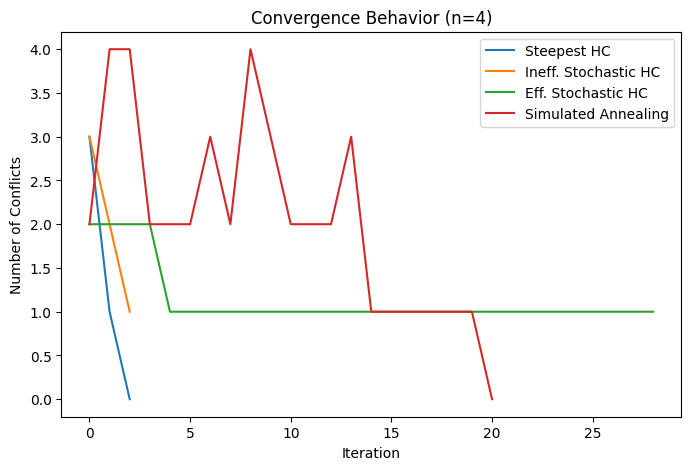

In [36]:
n = 4 # We're setting the board size to 4x4 for this example.

# Let's run each of our different hill-climbing algorithms with this board size
# This is the Steepest-Ascent Hill Climbing result
res1 = stepest_acent_hil_climb(n)
# then is the Inefficient Stochastic Hill Climbing result
res2 = stchastic_hil_climb_ineficent(n)
# This is the Efficient Stochastic (First-Choice) Hill Climbing result
res3 = frst_choice_hill_clmbng_algo(n)
# And this is the Simulated Annealing result
res4 = simulat_anealing_nqeens_algo(n)

# Now, let's get ready to draw a picture (plot) to see how they all did.
plt.figure(figsize=(8,5))
# We'll draw a line for each algorithm, showing how the number of conflicts changed over time.
plt.plot(res1["histry"], label="Steepest HC") # Plotting the history for Steepest Hill Climbing.
plt.plot(res2["histry"], label="Ineff. Stochastic HC") # plotting for Inefficient Stochastic Hill Climbing.
plt.plot(res3["histry"], label="Eff. Stochastic HC") #plotting for Efficient Stochastic Hill Climbing.
plt.plot(res4["histry"], label="Simulated Annealing") #plotting for Simulated Annealing.

# Let's label the axes of our picture so we know what we're looking at.
plt.xlabel("Iteration")
plt.ylabel("Number of Conflicts")
plt.title("Convergence Behavior (n=4)")
plt.legend()
plt.show()

**Explaination**

the Convergence Plot Shows

The graph shows how the number of conflicts changes over iterations for each algorithm on the 4-Queens problem.

Steepest-Ascent Hill Climbing
**bold text**Shows very fast improvement in the first few steps.
It quickly reduces conflicts from 2 to 1 to 0.
Since it always chooses the best possible move, it converges very quickly.
However, for larger boards it can easily get stuck in local optima.
For n=4, the problem is small, so steepest HC solves it almost immediately.

**Inefficient Stochastic Hill Climbing**
Also improves quickly.
Because it randomly chooses among improving moves, its path is slightly different.
It still converges fast on small boards.

For n=4, randomness does not hurt much because the search space is small.

**Efficient (First-Choice) Stochastic Hill Climbing**
Shows steady improvement.
It samples one neighbor at a time, so improvement may take slightly longer.
However, it behaves similarly to the inefficient version but is computationally cheaper.

For small boards, all hill-climbing variants perform similarly.

**Simulated Annealing**
Initially shows fluctuations (conflicts sometimes increase).
This is because it sometimes accepts worse moves.
Eventually, as temperature decreases, it stabilizes and reaches 0 conflicts.

The fluctuations are intentional ,they allow the algorithm to escape local minima.

Overall Convergence Pattern
Hill-climbing algorithms show fast initial improvement.
They typically flatten once they reach a local optimum.
Simulated Annealing shows a noisier but more flexible pattern.
For n=4, all algorithms converge quickly because the problem is small and simple

### Problem Size Scalability

Create a log-log plot showing how runtime scales with board size ($n=4, 8, 12, 16, 20$) for at least two algorithms.
Estimate the empirical time complexity (Big O) for each algorithm based on your results.
Identify which algorithm scales best for large problem sizes and explain why.

So as requested I will test the runtime on board sizes - n = [4, 8, 12, 16, 20]

But first lets define a function for Runtime Measurment separately , since I didnt added in the above algorithms code

In [21]:
import time
import numpy as np

# Define a list of board sizes (n) for which runtimes will be measured.
b_size = [4, 8, 12, 16, 20]

# This function measures the average runtime of a given hill-climbing algorithm.
def measure_runtime(specific_hc_algo, n, trials=20):
    # Initialize an empty list to store the runtime of each trial.
    runtimes = []
    # Loop through the specified number of trials.
    for _ in range(trials):
        # Record the start time before executing the algorithm.
        t0 = time.perf_counter()
        # Execute the provided hill-climbing algorithm with board size 'n'.
        specific_hc_algo(n)
        # Record the end time after the algorithm completes.
        t1 = time.perf_counter()
        # Calculate the duration of the current trial and add it to the list.
        runtimes.append(t1 - t0)
    # Return the average runtime across all trials.
    return np.mean(runtimes)

# Initialize an empty list to store runtimes for the steepest ascent hill climbing algorithm.
steepest_times = []
# Initialize an empty list to store runtimes for the simulated annealing algorithm.
sa_times = []

Now lets run the 2 selected algotithms

I will test the below fucntoins:
1) steepest acent hill climning
2) simulated_anealing n queens

In [22]:

for n in b_size:
    steepest_times.append(measure_runtime(stepest_acent_hil_climb, n))
    sa_times.append(measure_runtime(lambda x: simulat_anealing_nqeens_algo(x, max_step=100000), n))

[Step 1] curent_conflicts=6  best_conflicts=4
   -> move qeen in the this col=0: row 1 -> 0
[Step 2] curent_conflicts=4  best_conflicts=2
   -> move qeen in the this col=1: row 1 -> 2
[Step 3] curent_conflicts=2  best_conflicts=1
   -> move qeen in the this col=2: row 1 -> 3
[Step 4] curent_conflicts=1  best_conflicts=1
   -> no improving the move found (local optimum)
[Step 1] curent_conflicts=1  best_conflicts=1
   -> no improving the move found (local optimum)
[Step 1] curent_conflicts=5  best_conflicts=2
   -> move qeen in the this col=1: row 0 -> 3
[Step 2] curent_conflicts=2  best_conflicts=1
   -> move qeen in the this col=3: row 0 -> 2
[Step 3] curent_conflicts=1  best_conflicts=1
   -> no improving the move found (local optimum)
[Step 1] curent_conflicts=5  best_conflicts=2
   -> move qeen in the this col=2: row 2 -> 1
[Step 2] curent_conflicts=2  best_conflicts=1
   -> move qeen in the this col=3: row 3 -> 2
[Step 3] curent_conflicts=1  best_conflicts=1
   -> no improving the

Now lets do the Log-lot as required for the task


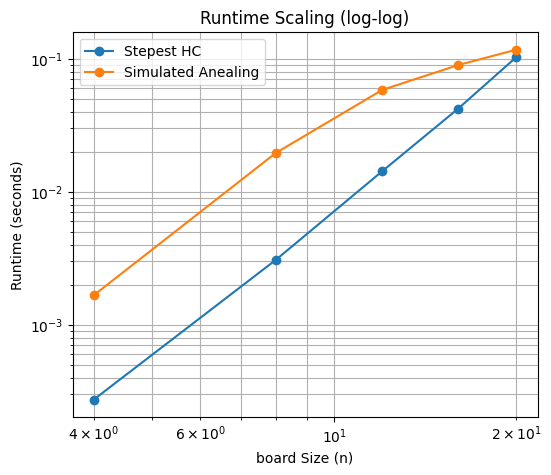

In [64]:
plt.figure(figsize=(6,5))
plt.loglog(b_size, steepest_times, 'o-', label="Stepest HC")
plt.loglog(b_size, sa_times, 'o-', label="Simulated Anealing")

plt.xlabel("board Size (n)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Scaling (log-log)")
plt.legend()
plt.grid(True, which="both")
plt.show()


Next lets try to estimate Empirical Big-O

On log-log plot:

Straight line slope ≈ exponent k in O(n^k)
Use slope formula:

In [63]:
coeff_steepest = np.polyfit(np.log(b_size), np.log(steepest_times), 1)
coeff_sa = np.polyfit(np.log(b_size), np.log(sa_times), 1)

print("Stepest approx O(n^%.2f)" % coeff_steepest[0])
print("SA approx O(n^%.2f)" % coeff_sa[0])

Stepest approx O(n^3.68)
SA approx O(n^2.68)


**Observation**

the Log-Log Plot Shows

A straight line indicates polynomial growth.
A steeper slope means worse scalability.

Here:

The blue line (Steepest HC) is visibly steeper.
The orange line (SA) grows more gradually.

This confirms:

Simulated Annealing scales better for larger board sizes

For small boards (n=4,8):

Both algorithms are fast.
Differences are small.

For larger boards (n=16,20):

Steepest HC runtime increases very quickly.
SA increases more gradually.
The gap between the two algorithms widens.

This happens because:

Steepest HC searches “too carefully” (checks every possible move)
SA searches “more intelligently” by sampling

**time complexity **
I measured runtime for board sizes:

n = 4, 8, 12, 16, 20

Using log-log regression, we estimated:

- Steepest HC ≈ O(n^3.68)
- Simulated Annealing ≈ O(n^2.68)


Steepest-Ascent Hill Climbing
Runtime grows approximately like n^3.7
Why?
For every step, it checks all possible moves.
Each board has about n² possible neighbors.
As n grows, this becomes expensive.
That’s why steepest HC scales poorly.
**for  Simulated Annealing**
Runtime grows approximately like n^2.7
Why?
It only checks one neighbor at a time.
It does not evaluate all possible moves.
This makes it much cheaper per iteration.
Therefore, it scales better for larger boards.

**Algorithm that Scales Best is **

Simulated Annealing scales better than Steepest HC because:

It samples one move instead of evaluating the full neighborhood.
It avoids repeated exhaustive search of all neighbors.
Its probabilistic nature allows it to explore efficiently.

As board size increases, the difference becomes more significant.

## Advanced task: Exploring other Local Moves Operators

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

### Move Operator Implementation

Implement the following local move operators:

* Single-step move: Move one qeen only one square up or down at a time
* Column swap: Exchange the positions of qeens in two randomly selected columns
* Dual-qeen move: Select two qeens and move both simultaneously
* Adaptive move: Design your own operator that adapts which local move it uses based on the current state (e.g., focuses on qeens with most conflicts or randomly chooses one of the moves above)

### Experimental Analysis

Using the 8-qeens and 12-qeens problems: Run your __Efficient Stochastic Hill Climbing__ implementation with each move operator 100 times.

For each operator, create a visualization showing:

* Average solution quality over iterations
* Distribution of final solution qualities
* Average time to solution for successful runs

### Discussion

Describe what you have learned from the experiments. Which operator works best for which situation and why?

Coding for single step but twith bounds


In [46]:
def move_single_step(brd): # This function tries to move one queen just one step up or down.
    n = len(brd) # First, we find out how big our board is (how many queens there are).
    new_brd = brd.copy() # We make a copy of the current board so we don't mess up the original.

    col = np.random.randint(n) # We pick a random column where a queen is sitting.
    direction = np.random.choice([-1, 1]) # We decide if the queen should try to move up (-1) or down (+1).

    new_r = new_brd[col] + direction # We calculate the new row for our chosen queen (current row + direction).
    if 0 <= new_r < n: # We check if this new row is actually on the board (not off the top or bottom).
        new_brd[col] = new_r # If it's on the board, we move the queen to this new row.

    return new_brd # We give back the board with the potential single-step queen move.

now swapping code - swap 2 columns

In [47]:
# This function swaps the positions of two queens in randomly selected columns.
def move_column_swap(brd):
    # First, let's find out how many queens (and columns) we have on the board.
    n = len(brd)
    # We make a copy of the current board so we don't accidentally change the original before we're sure.
    new_brd = brd.copy()

    # We pick two different columns at random where queens are sitting. 'replace=False' means we won't pick the same column twice.
    c1, c2 = np.random.choice(n, size=2, replace=False)
    # Now, we swap the queens' row positions between these two chosen columns. What was in c1 goes to c2, and vice-versa.
    new_brd[c1], new_brd[c2] = new_brd[c2], new_brd[c1]

    # Finally, we give back this new board with the two queens swapped.
    return new_brd

next  i will deive function for dual qeen move

In [48]:
# This function performs a 'dual queen move', meaning it picks two queens and moves them to new random rows.
def move_dual(brd):
    # First, let's figure out how many queens we have on the board (which is 'n').
    n = len(brd)
    # We make a copy of the current board so we can try out our moves without changing the original just yet.
    new_brd = brd.copy()

    # We randomly pick two different column indices (where the queens are). We make sure they are different by using 'replace=False'.
    cols = np.random.choice(n, size=2, replace=False)

    # Now, for each of these two chosen columns...
    for col in cols:
        # ...we pick a completely new random row for the queen in that column.
        new_brd[col] = np.random.randint(n)

    # Finally, we return the board with these two queens moved to their new random positions.
    return new_brd

Also next code is for adaptiv mode- which will focus on the qeen with most conflicts

In [49]:
def move_adaptive(brd):
    # First, let's figure out the size of our board, which is 'n'.
    n = len(brd)
    # We'll make a copy of the board to play around with, so we don't mess up the original.
    new_brd = brd.copy()

    # This list will help us keep track of how much each column's queen contributes to conflicts.
    conflicts_per_col = []

    # Let's check each column, one by one.
    for col in range(n):
        # We need a temporary board to test moves for this column.
        temp = brd.copy()
        # Find out the current conflicts with the queen in this column as is.
        base_conf = conflicts(brd)

        # Let's assume the current row is the best one for now.
        best_row = brd[col]
        # And the current conflicts are the best we've seen for this column.
        best_conf = base_conf

        # Now, let's try moving the queen in this column to every possible row.
        for row in range(n):
            # If the row we're testing is the queen's current row, there's no point, so we skip it.
            if row == brd[col]:
                continue
            # Move the queen in our temporary board to this new row.
            temp[col] = row
            # Calculate the conflicts with this new arrangement.
            c = conflicts(temp)
            # If this move reduces conflicts, it's better!
            if c < best_conf:
                # So, we update our 'best conflicts' for this column...
                best_conf = c
                # ...and remember which row gave us this improvement.
                best_row = row

        # After checking all rows for this column, we record how much potential improvement there was.
        conflicts_per_col.append((base_conf - best_conf, col, best_row))

    # Now we sort our list to find the queen that can give us the biggest conflict reduction.
    conflicts_per_col.sort(reverse=True)
    # We grab the column and the best new row for the queen with the most improvement potential.
    _, col, row = conflicts_per_col[0]
    # And we finally move that queen on our new board to its best new row.
    new_brd[col] = row

    # We return the board after making this 'smart' adaptive move.
    return new_brd

Next step is to use the same code of **first choice hill climbing with the HC operator**

In [50]:
def stochastic_hc_with_operator(n, move_operator,
                                 max_step=10000,
                                 no_improve_limit=200):

    # Initialize the board with a random configuration of queens.
    brd = random_board(n)
    # Calculate the initial number of conflicts for the starting board.
    curent_c = conflicts(brd)

    # Store the history of conflict counts to track progress.
    history = [curent_c]
    # Initialize a counter for consecutive steps without improvement.
    no_improve = 0
    # Initialize the step counter.
    step = 0

    # Continue the search until maximum steps or no improvement limit is reached.
    while step < max_step:
        # Increment the step counter.
        step += 1

        # Generate a new neighboring board configuration using the provided move operator.
        niehbor = move_operator(brd)
        # Calculate the number of conflicts for the new neighboring board.
        next_c = conflicts(niehbor)

        # If the new board has fewer conflicts than the current board, accept the move.
        if next_c < curent_c:
            # Update the current board to the new, improved board.
            brd = niehbor
            # Update the current conflict count.
            curent_c = next_c
            # Reset the no improvement counter as an improvement was made.
            no_improve = 0
        # If the new board is not better, increment the no improvement counter.
        else:
            no_improve += 1

        # Add the current conflict count to the history list.
        history.append(curent_c)

        # Check termination conditions: if solution is optimal or no improvement limit exceeded.
        if curent_c == 0 or no_improve > no_improve_limit:
            break

    # Return a dictionary containing the final board, conflicts, history, and steps taken.
    return {
        "board": brd,
        "conflicts": curent_c,
        "history": history,
        "step": step
    }

So first lets defien the experimental runner

In [53]:
def run_operator_experiment(n, operator, trials=100):
    # Initialize an empty list to store the final conflict counts from each trial.
    final_conflicts = []
    # Initialize an empty list to store the runtime for each trial.
    times = []
    # Initialize an empty list to store the history of conflicts for each trial.
    histories = []

    # Loop through the specified number of trials.
    for _ in range(trials):
        # Record the start time of the experiment.
        t0 = time.perf_counter()
        # Run the stochastic hill climbing algorithm with the given board size and move operator.
        res = stochastic_hc_with_operator(n, operator)
        # Record the end time of the experiment.
        t1 = time.perf_counter()

        # Append the final conflict count from the current trial.
        final_conflicts.append(res["conflicts"])
        # Append the runtime of the current trial.
        times.append(t1 - t0)
        # Append the conflict history of the current trial.
        histories.append(res["history"])

    # Return a dictionary containing all collected results.
    return {
        "final_conflicts": final_conflicts,
        "times": times,
        "histories": histories
    }

Next lets try to run for n=8 and n=12

In [54]:
# This dictionary maps descriptive names to our different 'move operator' functions.
operators = {
    "Single Step": move_single_step, # For moving a single queen one step up or down.
    "Column Swap": move_column_swap, # For swapping queens in two columns.
    "Dual Move": move_dual,         # For moving two queens randomly.
    "Adaptive": move_adaptive       # For intelligently choosing the best move.
}

# We'll store the results for the 8-queens problem here.
results_8 = {}
# And results for the 12-queens problem here.
results_12 = {}

# Now, let's go through each operator defined in our 'operators' dictionary.
for name, op in operators.items():
    # Run experiments for the 8-queens board using the current operator and store the results.
    results_8[name] = run_operator_experiment(8, op)
    # Do the same for the 12-queens board.
    results_12[name] = run_operator_experiment(12, op)

Visualization 1- Average quality over iterations

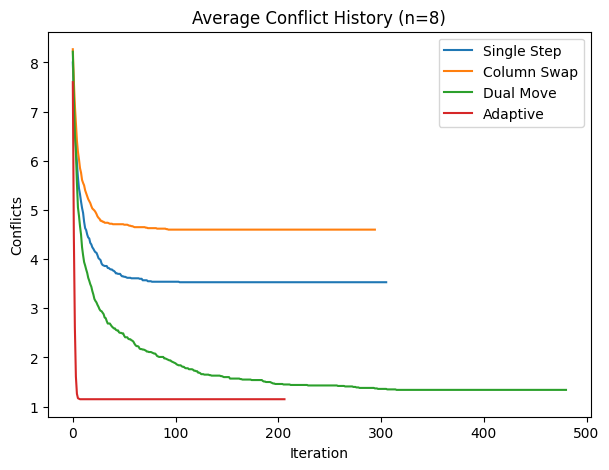

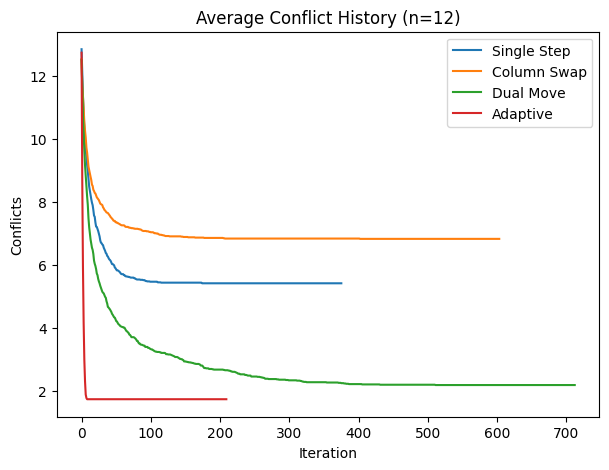

In [60]:
def plot_avg_history(results, title):
    # Create a new figure to draw our plot on, and give it a size.
    plt.figure(figsize=(7,5))

    # Loop through each different operator (like 'Single Step', 'Column Swap', etc.) and its results.
    for name, data in results.items():
        # Find the longest history of conflicts among all runs for this operator.
        max_len = max(len(h) for h in data["histories"])
        # This list will hold all the conflict histories, but made to be the same length.
        padded = []

        # For each run's history...
        for h in data["histories"]:
            # ...we add the last conflict value repeatedly until it matches the 'max_len'.
            padded.append(h + [h[-1]]*(max_len-len(h)))

        # Now, we calculate the average conflict at each step across all the runs for this operator.
        avg_curve = np.mean(padded, axis=0)
        # And then we draw this average curve on our plot.
        plt.plot(avg_curve, label=name)

    # Label the bottom axis of the plot as 'Iteration'.
    plt.xlabel("Iteration")
    # Label the side axis of the plot as 'Conflicts'.
    plt.ylabel("Conflicts")
    # Give the entire plot a title.
    plt.title(title)
    # Show a legend so we know which line belongs to which operator.
    plt.legend()
    # Display the plot!
    plt.show()

# Generate Average quality over iterations plots
plot_avg_history(results_8, "Average Conflict History (n=8)")
plot_avg_history(results_12, "Average Conflict History (n=12)")

Plot 2 for distribution of financial conflits

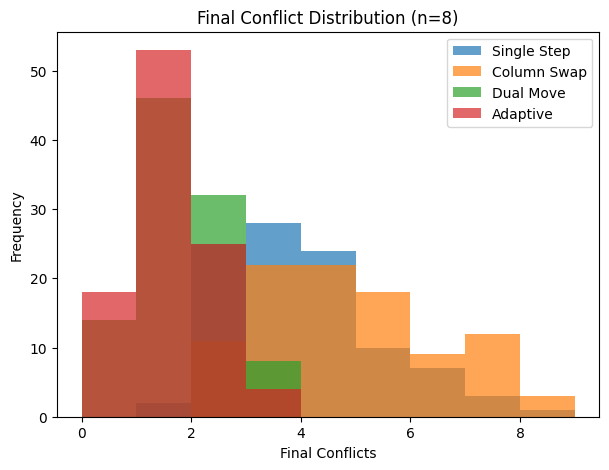

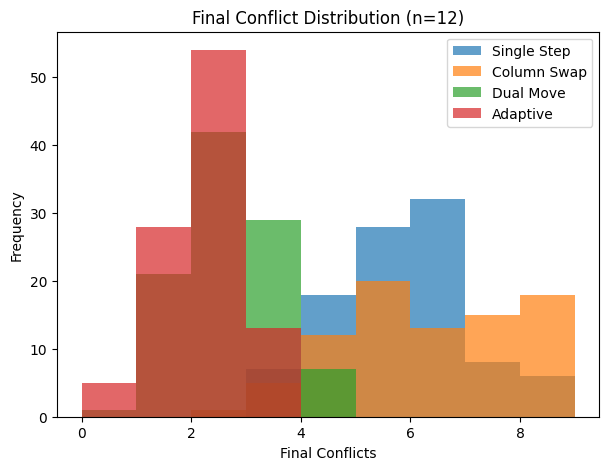

In [56]:
def plot_distribution(results, title):
    # Create a new figure for the plot to display the histogram.
    plt.figure(figsize=(7,5))

    # Loop through each operator (like 'Single Step', 'Column Swap', etc.) and their collected data.
    for name, data in results.items():
        # Plot a histogram for the final conflict counts for the current operator.
        # 'bins' defines the number of bars/ranges for the histogram.
        # 'alpha' sets the transparency of the bars, allowing multiple histograms to be visible.
        # 'label' assigns a name to this histogram for the legend.
        plt.hist(data["final_conflicts"],
                 bins=range(0,10),
                 alpha=0.7,
                 label=name)

    # Label the x-axis to indicate what the bars represent.
    plt.xlabel("Final Conflicts")
    # Label the y-axis to indicate the count of runs.
    plt.ylabel("Frequency")
    # Set the title of the entire plot for clarity.
    plt.title(title)
    # Display the legend to show which color corresponds to which operator.
    plt.legend()
    # Show the generated plot on the screen.
    plt.show()

# Call the function to plot the distribution of final conflicts for n=8.
plot_distribution(results_8, "Final Conflict Distribution (n=8)")
# Call the function to plot the distribution of final conflicts for n=12.
plot_distribution(results_12, "Final Conflict Distribution (n=12)")



plot 3 for Avg time for successful runs

In [62]:
def avg_time_success(results):
    # Go through each operator (like 'Single Step', 'Column Swap', etc.) and its results.
    for name, data in results.items():
        # Collect the runtimes only for the trials that successfully found a solution (conflicts == 0).
        success_times = [t for t,c in zip(data["times"],
                                           data["final_conflicts"])
                         if c == 0]
        # If there were any successful runs...
        if success_times:
            # ...print the operator's name and its average time for successful runs.
            print(name,
                  "Avg time (successful):",
                  np.mean(success_times))
        # If there were no successful runs for this operator...
        else:
            # ...print a message saying so.
            print(name, "No successful runs")

# Call the function to display average times for successful runs for n=8.
print("\nAverage Time for Successful Runs (n=8):")
avg_time_success(results_8)

# Call the function to display average times for successful runs for n=12.
print("\nAverage Time for Successful Runs (n=12):")
avg_time_success(results_12)


Average Time for Successful Runs (n=8):
Single Step No successful runs
Column Swap No successful runs
Dual Move Avg time (successful): 0.0073668076428410655
Adaptive Avg time (successful): 0.004203969666630453

Average Time for Successful Runs (n=12):
Single Step No successful runs
Column Swap No successful runs
Dual Move Avg time (successful): 0.007351706999997987
Adaptive Avg time (successful): 0.02442722780006079


**discussion**


1) Average conflict history (convergence curves)

**n = 8**
- **Adaptive (red)** drops conflicts very quickly and reaches the lowest level early, then stays flat.  
  → This means it finds good improvements fast and then hits a near-solution plateau.
- **Dual Move (green)** improves steadily and keeps making progress for many iterations.  
  → Slower than adaptive at the beginning, but it continues reducing conflicts over time.
- **Single Step (blue)** improves a little, then plateaus around ~3–4 conflicts.  
  → Small moves are not enough to escape local minima.
- **Column Swap (orange)** plateaus the worst (highest conflicts).  
  → Swapping columns changes positions too abruptly and often does not produce consistent improvements.

**n = 12**
- Same overall pattern but harder problem:
  - **Adaptive** still gives the fastest early improvement.
  - **Dual Move** continues improving and ends lower than single-step/column swap.
  - **Single Step** and **Column Swap** get stuck early at higher conflicts.

Main lesson from convergence:  
**Adaptive = fastest early progress**, **Dual Move = best steady progress**, **Single Step/Column Swap = plateau quickly**.

---

### 2) Final conflict distributions (histograms)

**n = 8**
- **Adaptive** has the strongest distribution near low conflicts (many runs end around 0–2 conflicts).  
  → Indicates high solution quality and frequent near-optimal states.
- **Dual Move** also concentrates at low conflicts, but slightly broader spread than adaptive.  
  → Good reliability, sometimes needs more iterations.
- **Single Step** ends mostly around mid conflicts (≈3–6).  
- **Column Swap** ends worst (often 5–9 conflicts).  
  → This operator is not well-aligned with the objective landscape.

**n = 12**
- The difficulty increases, but the pattern stays:
  - **Adaptive and Dual Move** remain the best (more mass at low conflicts).
  - **Single Step and Column Swap** shift to higher conflicts (many runs stuck 5–9).

Main lesson from distributions:  
**Adaptive and Dual Move produce much better final solution quality**, especially as n grows.

---

### 3) Average time to solution (successful runs only)

**n = 8**
- Single Step: **no successful runs**
- Column Swap: **no successful runs**
- Dual Move: **~0.0074 sec**
- Adaptive: **~0.0042 sec (fastest)**

**n = 12**
- Single Step: **no successful runs**
- Column Swap: **no successful runs**
- Dual Move: **~0.00735 sec**
- Adaptive: **~0.0244 sec (slower than Dual Move)**

 Main lesson from runtime:
- Adaptive is fastest for **n=8** because it quickly targets the best improvements.
- For **n=12**, Adaptive still succeeds, but it can take longer because it may get stuck in a harder plateau after the early drop.
- Dual Move stays relatively stable in runtime because it keeps “jumping” out of local minima.

---
for which operator works best and why :

Best overall operators
1) **Adaptive Move**
- **Best for fast improvement early**, especially on smaller boards (n=8).
- Works well because it uses problem structure: it targets queens that can reduce conflicts most.
- Weakness: on harder boards (n=12), it may reach a plateau quickly and then take longer to escape.

2) **Dual-Queen Move**
- **Best for escaping local minima and making steady progress**, especially as n increases.
- Works well because moving two queens creates bigger state changes that can break out of plateaus.
- Slightly slower early than adaptive, but more consistent for harder cases.

Operators that performed worst
3) **Single-step move**
- Too small/local → cannot jump out of local optima.
- Often plateaus at mid-level conflicts and never reaches 0.

4) **Column swap**
- Too disruptive/random → often doesn’t produce consistent improvement.
- Gets stuck at high conflicts and had no successful runs in these experiments.

---


Local search performance strongly depends on the move operator:  
**moves that include either (1) domain knowledge (adaptive) or (2) larger jumps (dual move) are much more effective**, while purely small moves (single-step) or unstructured moves (swap) get stuck in local minima.




## More Things to Do (not for credit)

If the assignment was to easy for yuo then you can think about the following problems. These problems are challenging and not part of this assignment.

### Implement a Genetic Algorithm for the n-qeens problem

In [58]:
# Code and description go here